In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quant_ml.config import INTERIM_DATA_DIR
from quant_ml.models import time_split, fit_predict_logistic
from quant_ml.signals import make_weekly_top_n_signals, equal_weight_from_signal
from quant_ml.baseline import compute_strategy_returns

In [3]:
df = pd.read_parquet(INTERIM_DATA_DIR / "model_dataset_v1.parquet")
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(20490, 27)


,date,ticker,open,high,low,close,volume,fed_funds,cpi,unemployment,...,ma_ratio_20,ma_ratio_50,ma_ratio_100,ma_cross_20_50,vol_20d,vol_60d,volume_z_20,volume_ratio_20,fwd_ret_5d,target_up_5d
0,2012-05-24,EEM,27.678185,27.685539,27.192732,27.457525,57707700,0.16,228.713,8.2,...,-0.064118,-0.101638,-0.110964,-0.040091,0.010547,0.012934,-0.023332,0.993897,-0.017145,0.0
1,2012-05-25,EEM,27.347199,27.486950,27.251579,27.325134,47685000,0.16,228.713,8.2,...,-0.062567,-0.102952,-0.114840,-0.043080,0.010403,0.012836,-0.726949,0.815904,-0.008076,0.0
2,2012-05-29,EEM,28.060670,28.215132,27.854718,28.097446,71172100,0.16,228.713,8.2,...,-0.031157,-0.074966,-0.089674,-0.045218,0.012968,0.013456,0.776170,1.185941,-0.032723,0.0
3,2012-05-30,EEM,27.560501,27.692897,27.435458,27.611988,80092500,0.16,228.713,8.2,...,-0.041870,-0.088131,-0.105153,-0.048282,0.012950,0.013457,1.279838,1.289009,0.013053,1.0
4,2012-05-31,EEM,27.663479,27.869428,27.376621,27.729677,66528900,0.16,228.713,8.2,...,-0.031956,-0.081809,-0.101227,-0.051499,0.013127,0.012851,0.225904,1.044534,0.014854,1.0


In [4]:
feature_cols = [
    "ret_1d", "ret_5d", "ret_20d", "ret_60d",
    "ma_ratio_20", "ma_ratio_50", "ma_ratio_100", "ma_cross_20_50",
    "vol_20d", "vol_60d",
    "volume_z_20", "volume_ratio_20",
    "fed_funds", "cpi", "unemployment", "10y_treasury", "2y_treasury", "term_spread",
]

target_col = "target_up_5d"

In [5]:
split = time_split(df, train_end_date="2020-12-31")

train_df = split.train
test_df = split.test

print("train:", train_df.shape)
print("test:", test_df.shape)
print(train_df["date"].min(), train_df["date"].max())
print(test_df["date"].min(), test_df["date"].max())

train: (12996, 27)
test: (7494, 27)
2012-05-24 00:00:00 2020-12-31 00:00:00
2021-01-04 00:00:00 2025-12-22 00:00:00


In [6]:
model, preds = fit_predict_logistic(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols,
    target_col=target_col,
)

preds.head()

,date,ticker,close,fwd_ret_5d,proba_up,pred_label
2166,2021-01-04,EEM,46.271252,0.037885,0.572734,1
2167,2021-01-05,EEM,47.383541,0.023474,0.542672,1
2168,2021-01-06,EEM,46.983116,0.034470,0.578313,1
2169,2021-01-07,EEM,47.428032,0.034334,0.590525,1
2170,2021-01-08,EEM,48.682697,-0.006580,0.523103,1


In [7]:
preds["proba_up"].describe()

count    7494.000000
mean        0.691478
std         0.043493
min         0.498945
25%         0.663978
50%         0.692605
75%         0.721431
max         0.841591
Name: proba_up, dtype: float64

In [8]:
preds["pred_label"].value_counts(normalize=True)

pred_label
1    0.999867
0    0.000133
Name: proportion, dtype: float64

In [9]:
ml_df = make_weekly_top_n_signals(
    preds,
    score_col="proba_up",
    top_n=2,
)

ml_df = equal_weight_from_signal(ml_df)
ml_df.head()

,date,ticker,close,fwd_ret_5d,proba_up,pred_label,week,signal,weight
0,2021-01-04,EEM,46.271252,0.037885,0.572734,1,2021-01-04/2021-01-10,0.0,0.0
1,2021-01-05,EEM,47.383541,0.023474,0.542672,1,2021-01-04/2021-01-10,0.0,0.0
2,2021-01-06,EEM,46.983116,0.034470,0.578313,1,2021-01-04/2021-01-10,0.0,0.0
3,2021-01-07,EEM,47.428032,0.034334,0.590525,1,2021-01-04/2021-01-10,0.0,0.0
4,2021-01-08,EEM,48.682697,-0.006580,0.523103,1,2021-01-04/2021-01-10,0.0,0.0


In [10]:
ml_portfolio = compute_strategy_returns(ml_df)
ml_portfolio.head()

,gross_return,cost,net_return,cum_return
date,,,,
2021-01-04,0.0,0.000,0.000,1.000
2021-01-05,0.0,0.000,0.000,1.000
2021-01-06,0.0,0.000,0.000,1.000
2021-01-07,0.0,0.000,0.000,1.000
2021-01-08,0.0,0.001,-0.001,0.999


In [11]:
returns = ml_portfolio["net_return"].dropna()

ml_sharpe = np.sqrt(252) * returns.mean() / returns.std()
ml_max_dd = (ml_portfolio["cum_return"] / ml_portfolio["cum_return"].cummax() - 1).min()

print("ML Sharpe:", ml_sharpe)
print("ML Max Drawdown:", ml_max_dd)

ML Sharpe: 0.5486839800570537
ML Max Drawdown: -0.20351268568888947


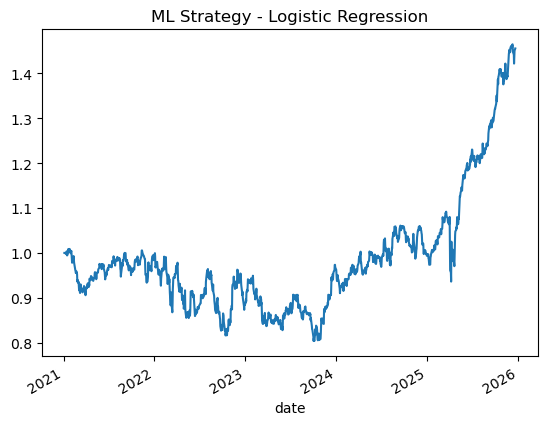

In [12]:
ml_portfolio["cum_return"].plot(title="ML Strategy - Logistic Regression")
plt.show()